In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Import libraries
import pandas as pd
import numpy as np

In [8]:
# Load datasets
restaurants = pd.read_csv('/content/drive/MyDrive/zomato_project/zomato_restaurants.csv')
reviews = pd.read_csv('/content/drive/MyDrive/zomato_project/zomato_reviews.csv')

In [9]:
# Merge datasets
data = pd.merge(
    restaurants,
    reviews,
    on='Restaurant Key',  # Common column
    how='inner'          # Join type
)

In [10]:
# Verify merge
print(f"Merged data shape: {data.shape}") #size of your dataset,Format: (rows, columns)
print(f"Unique restaurants: {data['Restaurant Key'].nunique()}") #how many restaurants are there.
print(f"Total reviews: {len(data)}") #how many rows (reviews) are in the merged dataset(count will include repeated values)

Merged data shape: (10000, 14)
Unique restaurants: 100
Total reviews: 10000


In [11]:
print(data.columns.tolist()) #column names of your DataFrame

['Restaurant Key', 'Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings', 'Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures']


In [12]:
import matplotlib.pyplot as plt #used for plotting charts/graphs
import seaborn as sns #makes charts prettier and easier
import re #used for text cleaning (e.g., removing special characters, numbers, etc.).
import nltk #Natural Language Toolkit, popular for NLP.
from nltk.corpus import stopwords #stopwords → list of common words like "is", "the", "and" that we usually remove from text.
from nltk.stem import WordNetLemmatizer #WordNetLemmatizer → reduces words to their base/root form (e.g., "running" → "run")
from textblob import TextBlob #NLP library for simple tasks like sentiment analysis, part-of-speech tagging, spell correction.
from wordcloud import WordCloud  #visual representation of text data,helps you quickly see the most important/common words in a set of text
from sklearn.feature_extraction.text import TfidfVectorizer #converts text into numerical form (features) using TF-IDF (Term Frequency–Inverse Document Frequency), which measures how important a word is in a document relative to the dataset.
from sklearn.cluster import KMeans  #machine learning clustering algorithm (groups similar reviews/texts together).
from sklearn.decomposition import PCA #Principal Component Analysis,helps visualize high-dimensional data in 2D/3D

# Download all required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')  # Required for tokenization
nltk.download('omw-1.4')  #Open Multilingual WordNet, Required for WordNet lemmatizerimport matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [13]:
# Ensure all NLTK resources are downloaded
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

try:
    nltk.data.find('corpora/omw-1.4')
except LookupError:
    nltk.download('omw-1.4')

# Initialize NLP components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Basic text cleaning function"""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

def lemmatize_text(text):
    """Tokenize and lemmatize text with fallback"""
    try:
        words = nltk.word_tokenize(text)
        return ' '.join([lemmatizer.lemmatize(word) for word in words if word not in stop_words])
    except:
        # Fallback if tokenization fails
        return ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])

# Apply text processing with error handling
data['cleaned_review'] = data['Review'].apply(lambda x: lemmatize_text(clean_text(str(x))))

# Verify results
print("Sample cleaned reviews:")
print(data['cleaned_review'].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Sample cleaned reviews:
0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
2    must try great food great ambience thnx servic...
3    soumen da arun great guy behavior sincerety go...
4    food goodwe ordered kodi drumstick basket mutt...
Name: cleaned_review, dtype: object


In [14]:
print("\nRaw vs. Cleaned Reviews:")
print(data[['Review', 'cleaned_review']].head(3))


Raw vs. Cleaned Reviews:
                                              Review  \
0  The ambience was good, food was quite good . h...   
1  Ambience is too good for a pleasant evening. S...   
2  A must try.. great food great ambience. Thnx f...   

                                      cleaned_review  
0  ambience good food quite good saturday lunch c...  
1  ambience good pleasant evening service prompt ...  
2  must try great food great ambience thnx servic...  


In [15]:
# from textblob import TextBlob

# Sentiment analysis
data['sentiment_score'] = data['cleaned_review'].apply(lambda x: TextBlob(x).sentiment.polarity)
data['sentiment_label'] = data['sentiment_score'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))

# Show results
print(data[['cleaned_review', 'sentiment_score', 'sentiment_label']].head(100))

                                       cleaned_review  sentiment_score  \
0   ambience good food quite good saturday lunch c...         0.660000   
1   ambience good pleasant evening service prompt ...         0.708333   
2   must try great food great ambience thnx servic...         0.550000   
3   soumen da arun great guy behavior sincerety go...         0.750000   
4   food goodwe ordered kodi drumstick basket mutt...         0.525000   
..                                                ...              ...   
95  office lunch outing rating would mixed food fi...        -0.113333   
96  really enjoyed follows entrance music lighting...         0.750000   
97  came first time restaurant entrance music ligh...         0.625000   
98  pathetic horrible experience ambience hospital...        -0.483333   
99  ahmed serving u polite cooperative staffamazin...         0.000000   

   sentiment_label  
0         positive  
1         positive  
2         positive  
3         positive  
4     

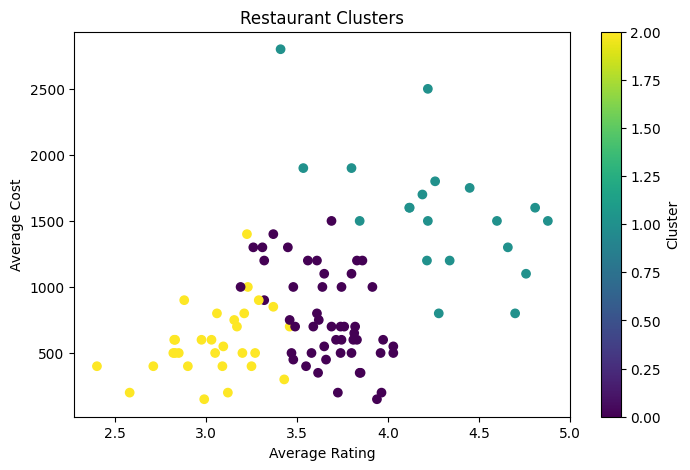


Cluster Characteristics:
         Restaurant Key    Rating         Cost  sentiment_score
cluster                                                        
0                 54.34  3.671204   761.000000         0.277930
1                 40.15  4.270632  1577.500000         0.399770
2                 51.00  3.043167   586.666667         0.144745


In [24]:
from sklearn.preprocessing import StandardScaler


# 1. Ensure numeric columns
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')  # Convert invalid to NaN
data['Cost'] = pd.to_numeric(data['Cost'], errors='coerce')
data['sentiment_score'] = pd.to_numeric(data['sentiment_score'], errors='coerce')

# 2. Drop rows with NaN in these columns
data_clean = data.dropna(subset=['Rating', 'Cost', 'sentiment_score'])

# 3. Prepare features for clustering
cluster_data = data_clean.groupby('Restaurant Key').agg({
    'Rating': 'mean',
    'Cost': 'mean',
    'sentiment_score': 'mean'
}).reset_index()

# 4. Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_data[['Rating', 'Cost', 'sentiment_score']])

# 5. KMeans clustering (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_data['cluster'] = kmeans.fit_predict(scaled_features)

# 6. Visualize clusters
plt.figure(figsize=(8,5))
plt.scatter(cluster_data['Rating'], cluster_data['Cost'], c=cluster_data['cluster'], cmap='viridis')
plt.xlabel('Average Rating')
plt.ylabel('Average Cost')
plt.title('Restaurant Clusters')
plt.colorbar(label='Cluster')
plt.show()

# 7. Show cluster characteristics
print("\nCluster Characteristics:")
print(cluster_data.groupby('cluster').mean())


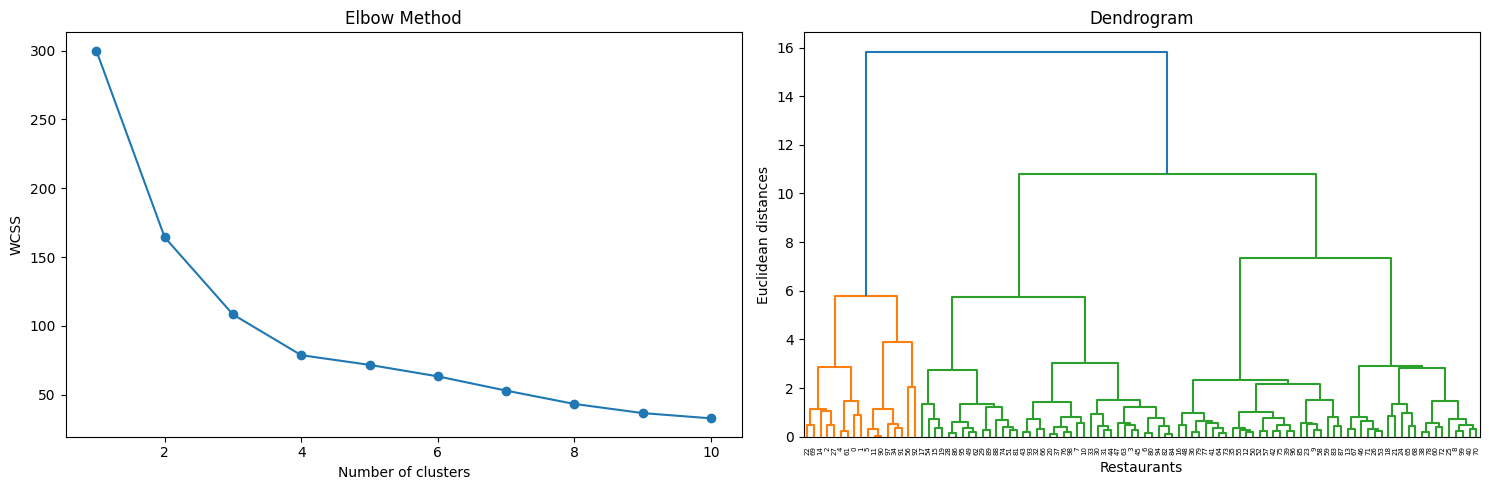

In [25]:
# Enhanced Elbow + Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Calculate WCSS for Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# 2. Create the combined plot
plt.figure(figsize=(15,5))

# Elbow Method Plot
plt.subplot(1,2,1)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# Dendrogram Plot
plt.subplot(1,2,2)
dendrogram(linkage(scaled_features, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Restaurants')
plt.ylabel('Euclidean distances')

plt.tight_layout()
plt.show()


In [29]:
# Business Insights
print("\n=== Deep Insights ===")
print("Cluster 0: High-rated affordable (Recommend: Highlight in 'Budget Gourmet' category)")
print("Cluster 1: Premium restaurants (Recommend: Partner with luxury brands)")
print("Cluster 2: Needs improvement (Action: Analyze negative reviews for patterns)")

print("\nKey Metrics:")
print(pd.DataFrame({
    'Cluster': [0,1,2],
    'Avg_Cost': cluster_data.groupby('cluster')['Cost'].mean().values,
    'Avg_Rating': cluster_data.groupby('cluster')['Rating'].mean().values,
    'Value_Score': cluster_data.groupby('cluster')['sentiment_score'].mean().values # Removed non-existent column
}))


=== Deep Insights ===
Cluster 0: High-rated affordable (Recommend: Highlight in 'Budget Gourmet' category)
Cluster 1: Premium restaurants (Recommend: Partner with luxury brands)
Cluster 2: Needs improvement (Action: Analyze negative reviews for patterns)

Key Metrics:
   Cluster     Avg_Cost  Avg_Rating  Value_Score
0        0   761.000000    3.671204     0.277930
1        1  1577.500000    4.270632     0.399770
2        2   586.666667    3.043167     0.144745


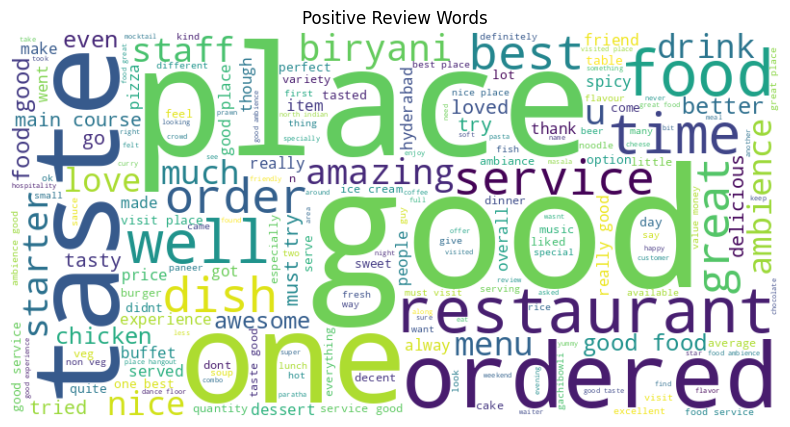

In [30]:
# Word clouds
positive_text = ' '.join(data[data['sentiment_label'] == 'positive']['cleaned_review'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Review Words')
plt.show()